<h1>Pretpocesiranje i analiza podataka</h1>
<h2>Uvođenje potrebnih paketa</h2>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
from sklearn import preprocessing
from sklearn import feature_selection

In [19]:
from scipy import stats

<h2>Učitavanje podataka</h2>

In [20]:
loaded_data = pd.read_excel("career_dataset_large.xlsx")

In [21]:
data = loaded_data

<h2>Opis podataka</h2>
Naš skup podataka se sastoji od 6 atributa, od čega je 5 kategoričkih i samo jedan numerički. U kategoričke atribute spadaju: Education Level, Specialization, Skills, Certifications i Recommended Career, a u numeričke CGPA/Percentage. Ciljna promenljiva je Recommended Career, dakle cilj je napraviti model koji može predvideti koju je karijeru najbolje predvideti u zavisnosti od poznatog nivoa obrazovanja, specijalizacije, veština, sertifikata i proseka neke osobe.

In [22]:
data

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst
3,Bachelor's,Computer Science,Communication,NaN,75,Clerk
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant
...,...,...,...,...,...,...
4995,Matric,Commerce,"Accounting, Python",Tally ERP,90,Clerk
4996,Master's,Business,Python,Creative Writing,92,School Counselor
4997,Matric,Computer Science,Financial Analysis,Digital Marketing,63,Financial Analyst
4998,PhD,Engineering,"Python, Machine Learning, Data Analysis",NaN,83,Software Engineer


In [23]:
data.describe()

,CGPA/Percentage
count,5000.000000
mean,77.479800
std,10.396288
min,60.000000
25%,68.000000
50%,77.000000
75%,87.000000
max,95.000000


In [24]:
def bar_categorical(data, label, title = None, xlabel = 'Classes', ylabel='Counts'):
    if title is None: title = label
    plt.bar(data[label].value_counts().index, data[label].value_counts().values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation='vertical')
    plt.show()

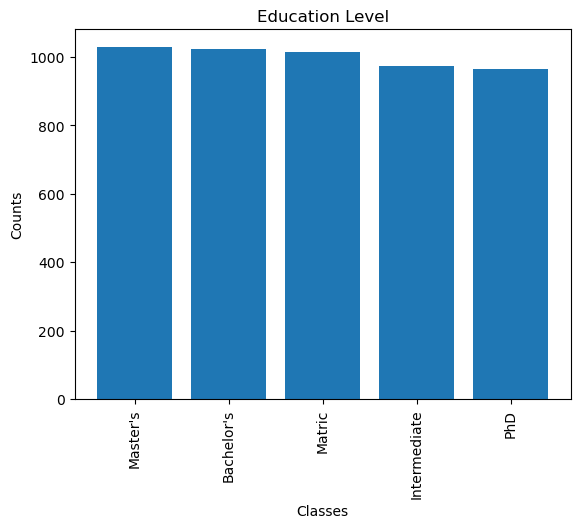

In [25]:
bar_categorical(data, 'Education Level')

In [26]:
data['Specialization'].value_counts().index

Index(['Engineering', 'Finance', 'Psychology', 'Business', 'Computer Science',
       'Arts', 'Commerce', 'Science'],
      dtype='object', name='Specialization')

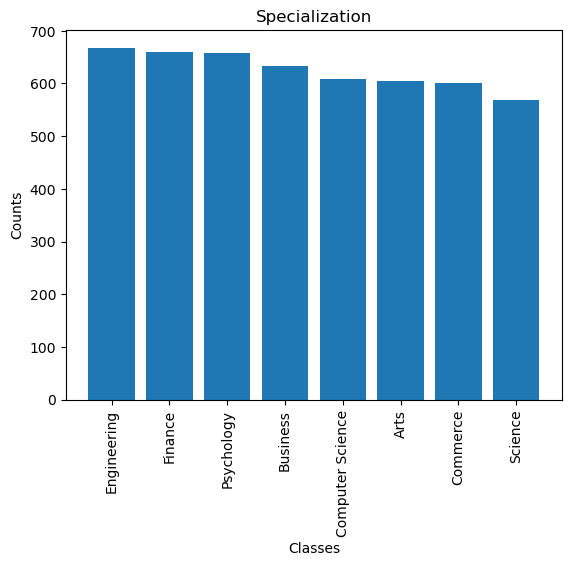

In [27]:
bar_categorical(data, 'Specialization')

In [28]:
skills_for_plot = {}
for skill in data['Skills']:
    for s in skill.split(', '):
        if s in skills_for_plot:
            skills_for_plot[s]+=1
        else:
            skills_for_plot[s]=1


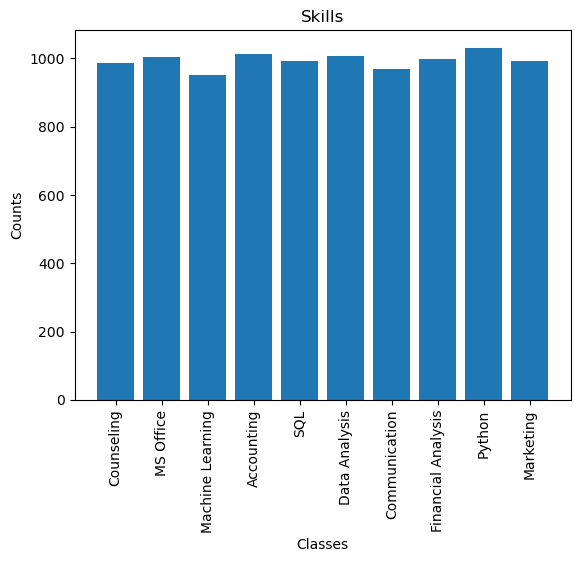

In [29]:
plt.bar(skills_for_plot.keys(), skills_for_plot.values())
plt.title('Skills')
plt.xticks(rotation='vertical')
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.show()

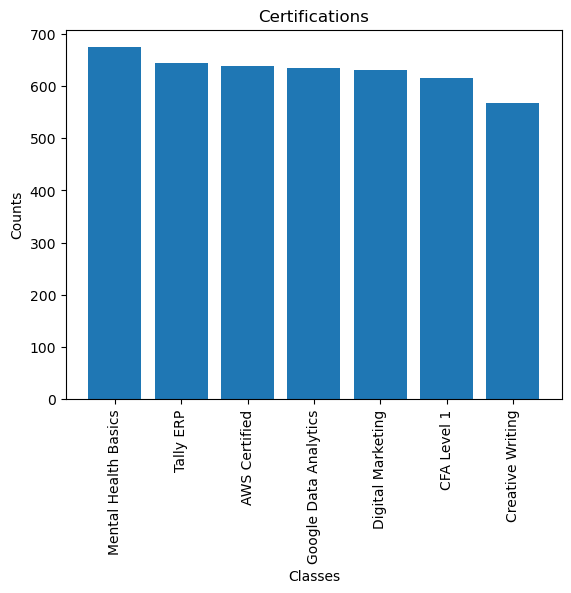

In [30]:
bar_categorical(data, 'Certifications')

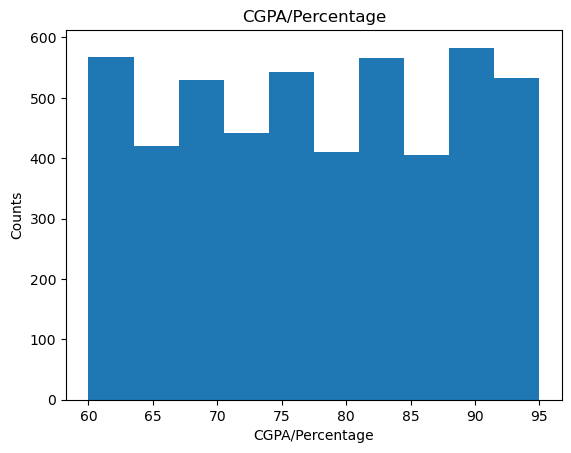

In [31]:
plt.hist(data['CGPA/Percentage'])
plt.title('CGPA/Percentage')
plt.xlabel('CGPA/Percentage')
plt.ylabel('Counts')
plt.show()

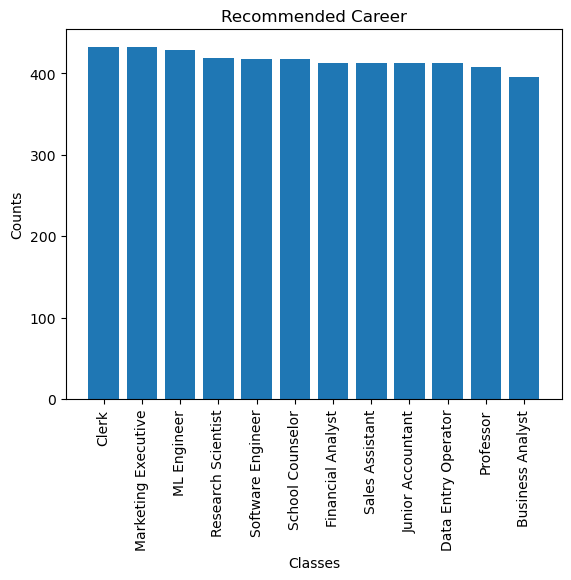

In [32]:
bar_categorical(data, 'Recommended Career')

Na osnovu deskriptivne statistike vidimo da je skup podataka veoma dobro izbalansiran što se i očekivalo s obzirom da je skup podataka sintetički generisan

<h2>Binarizacija nominalnih kategoričkih promenljivih</h2>
U okviru našeg skupa podataka imamo tri nominalna kategorička atributa, to su: Specialization, Skills i Sertifications. Binarizaciju ovih atributa smo vršili ručno tako što smo najpre napravili rečnik svih jedinstvenih vrednosti u okviru svakog atributa koji se mapiraju na indeks kolone u kojoj se atribut kojem ta vrednost pripada nalazi u skupu podataka, a zatim smo dodali nove kolone(atribute) čija su imena jednaka prethodno pomenutim jedinstvenim vrednostima i koji uzimaju vrednost 1 ako se u redu podatka nalazi data vrednost u koloni koja je mapirana pomoću rečnika, a 0 u suprotnom. Kolone koje se ne nalaze u rečniku se samo prepisuju u izmenjen skup podataka.

Pravljenje rečnika

In [33]:
columns_to_binarize = [ 1, 2, 3]
binary_to_index = {}

for column_index in columns_to_binarize:
    for value in data.iloc[:, column_index]:
        if pd.notna(value):
            for splits in str(value).split(', '):
                binary_to_index[splits] = column_index
binary_to_index

{'Finance': 1,
 'Science': 1,
 'Business': 1,
 'Computer Science': 1,
 'Arts': 1,
 'Psychology': 1,
 'Commerce': 1,
 'Engineering': 1,
 'Counseling': 2,
 'MS Office': 2,
 'Machine Learning': 2,
 'Accounting': 2,
 'SQL': 2,
 'Data Analysis': 2,
 'Communication': 2,
 'Financial Analysis': 2,
 'Python': 2,
 'Marketing': 2,
 'Tally ERP': 3,
 'AWS Certified': 3,
 'Mental Health Basics': 3,
 'Digital Marketing': 3,
 'CFA Level 1': 3,
 'Creative Writing': 3,
 'Google Data Analytics': 3}

Izdvajanje atributa iz skupa podataka

In [34]:
feature_names = ['Education Level'] + list(binary_to_index.keys()) + ['CGPA/Percentage']
feature_names

['Education Level',
 'Finance',
 'Science',
 'Business',
 'Computer Science',
 'Arts',
 'Psychology',
 'Commerce',
 'Engineering',
 'Counseling',
 'MS Office',
 'Machine Learning',
 'Accounting',
 'SQL',
 'Data Analysis',
 'Communication',
 'Financial Analysis',
 'Python',
 'Marketing',
 'Tally ERP',
 'AWS Certified',
 'Mental Health Basics',
 'Digital Marketing',
 'CFA Level 1',
 'Creative Writing',
 'Google Data Analytics',
 'CGPA/Percentage']

In [35]:
target = 'Recommended Career'

Inicijalizacija novog pandas data frame-a koji će se popuniti binarizovanim nominalnim kategoričkim atributima

In [36]:
binarized_attributes = pd.DataFrame(np.zeros( (len(data), len(feature_names)), dtype=int), columns = feature_names)

In [37]:
for index in range(len(feature_names)):
    feature_name = feature_names[index]
    if feature_name not in binary_to_index:
        binarized_attributes[feature_name] = data[feature_name]
        continue
        
    column_index = binary_to_index[feature_name]

    for row in range(len(data)):
        value = data.iloc[row, column_index]
        if pd.notna(value):
            split = value.split(', ')
            binarized_attributes.iloc[row, index] = int(feature_name in split)

binarized_attributes

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Python,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage
0,Bachelor's,1,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,67
1,Intermediate,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,67
2,Master's,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,90
3,Bachelor's,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,75
4,Matric,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Matric,0,0,0,0,0,0,1,0,0,...,1,0,1,0,0,0,0,0,0,90
4996,Master's,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,92
4997,Matric,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,63
4998,PhD,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,83


In [38]:
data = binarized_attributes.join(data[target])
data.head()

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage,Recommended Career
0,Bachelor's,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,67,Business Analyst
1,Intermediate,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,67,Software Engineer
2,Master's,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,90,Financial Analyst
3,Bachelor's,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,75,Clerk
4,Matric,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,83,Sales Assistant


<h2>Ordinalno enkodiranje ordinalne kategoričke promenljive</h2>
U okviru našeg skupa podataka imamo samo jednu ordinalnu kategoričku promenljivu: Education Level.

In [39]:
ordinalEncoder = preprocessing.OrdinalEncoder(categories=[['Matric', 'Intermediate', 'Bachelor\'s', 'Master\'s', 'PhD']], dtype='int')
data['Education Level'] = ordinalEncoder.fit_transform(data[['Education Level']])
data.head()

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage,Recommended Career
0,2,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,67,Business Analyst
1,1,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,67,Software Engineer
2,3,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,90,Financial Analyst
3,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,75,Clerk
4,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,83,Sales Assistant


<h2>Label enkodiranje ciljne promenljive</h2>

In [40]:
features = data.drop(target, axis=1)
target_binarized = data[target]

label_encoder= preprocessing.LabelEncoder()
target_encoded = label_encoder.fit_transform( data[target] )

target_encoded

array([ 0, 11,  3, ...,  3, 11,  1], shape=(5000,))

<h2>Analiza podataka</h2>
U nastavku ćemo izvršiti analizu korelacija između atributa i ciljne promenljive, kao i atributa međusobno u cilju procene koji od atributa je najvažniji za predviđanje ciljne promenljive, kao i izbegavanje korišćenja atributa koji su u velikoj meri korelisani kako bi se smanjila složenost modela, a potencijalno i poboljšao njegov kvalitet.
<br><br>
Za nalaženje značajnosti atributa pri predviđanju ciljne promenljive koristili smo funkciju mutual_info_classif iz paketa feature_selection modula sklearn.

In [41]:
MI = feature_selection.mutual_info_classif(features, target_encoded, discrete_features=True, random_state=7)
MI

array([0.0051546 , 0.00076008, 0.00063001, 0.00131601, 0.00129907,
       0.00097352, 0.00134064, 0.0015886 , 0.00191191, 0.00176754,
       0.00065909, 0.0011309 , 0.00056029, 0.00084064, 0.00168499,
       0.00145988, 0.00224995, 0.00295411, 0.00166847, 0.00156991,
       0.00138062, 0.00068429, 0.00059399, 0.0009698 , 0.00104179,
       0.00111881, 0.03334199])

In [42]:
mi_series = pd.Series(MI, index=features.columns).sort_values(ascending=False)

print(mi_series)

CGPA/Percentage          0.033342
Education Level          0.005155
Python                   0.002954
Financial Analysis       0.002250
Engineering              0.001912
Counseling               0.001768
Data Analysis            0.001685
Marketing                0.001668
Commerce                 0.001589
Tally ERP                0.001570
Communication            0.001460
AWS Certified            0.001381
Psychology               0.001341
Business                 0.001316
Computer Science         0.001299
Machine Learning         0.001131
Google Data Analytics    0.001119
Creative Writing         0.001042
Arts                     0.000974
CFA Level 1              0.000970
SQL                      0.000841
Finance                  0.000760
Mental Health Basics     0.000684
MS Office                0.000659
Science                  0.000630
Digital Marketing        0.000594
Accounting               0.000560
dtype: float64


Koeficijenti su iz opsega [0, 1] pri čemu 1 označava atribut koji se može koristiti da savršeno dobro predvidi vrednosti ciljne promenljive, a 0 označava atribut na osnovu čije vrednosti se ništa ne može zaključiti o ciljnoj promenljivoj. Vidimo da nijedan atribut nije od velike značajnosti za predviđanje ciljne promenljive.

Dalje pravimo pomoćan data frame za određivanje zavisnosti među kategoričkim atributima

In [43]:
data_with_separated_skills = loaded_data.drop(['Skills', 'CGPA/Percentage', 'Recommended Career'], axis=1)
data_with_separated_skills

,Education Level,Specialization,Certifications
0,Bachelor's,Finance,Tally ERP
1,Intermediate,Science,AWS Certified
2,Master's,Business,Mental Health Basics
3,Bachelor's,Computer Science,NaN
4,Matric,Business,Tally ERP
...,...,...,...
4995,Matric,Commerce,Tally ERP
4996,Master's,Business,Creative Writing
4997,Matric,Computer Science,Digital Marketing
4998,PhD,Engineering,NaN


In [44]:
data_with_separated_skills = data_with_separated_skills.join(loaded_data["Skills"].str.get_dummies(sep=", "))
data_with_separated_skills

,Education Level,Specialization,Certifications,Accounting,Communication,Counseling,Data Analysis,Financial Analysis,MS Office,Machine Learning,Marketing,Python,SQL
0,Bachelor's,Finance,Tally ERP,0,0,1,0,0,1,1,0,0,0
1,Intermediate,Science,AWS Certified,1,0,0,0,0,1,0,0,0,0
2,Master's,Business,Mental Health Basics,1,0,0,1,0,0,0,0,0,1
3,Bachelor's,Computer Science,NaN,0,1,0,0,0,0,0,0,0,0
4,Matric,Business,Tally ERP,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Matric,Commerce,Tally ERP,1,0,0,0,0,0,0,0,1,0
4996,Master's,Business,Creative Writing,0,0,0,0,0,0,0,0,1,0
4997,Matric,Computer Science,Digital Marketing,0,0,0,0,1,0,0,0,0,0
4998,PhD,Engineering,NaN,0,0,0,1,0,0,1,0,1,0


Za procenu nezavisnoti kategoričkih atributa u odnosu na ciljnu promenljivu koristimo hi kvadrat test nezavisnosti kao i metriku Cramer's V koja nam daje vrednost od 0 do 1 za bolju procenu zavisnosti među promenljivima, a ta vrednost se naziva koeficijent nepredviđenosti.
Koeficijent se računa po sledećoj formuli:<br><br>
<img src="formula.png">
Gde su:<br>
    &chi;&sup2; - hi kvadrat statistika<br>
    n - broj observacija<br>
    k - broj jedinstvenih vrednosti prvog atributa<br>
    r - broj jedinstvenih vrednosti drugog atributa<br>

In [45]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

In [46]:
categorical_features = data_with_separated_skills.columns
cramers_vs = []

for feature in categorical_features:
    cramers_vs.append(cramers_v(data_with_separated_skills[feature], data[target]))

cramers_vs

[np.float64(0.05077757260753958),
 np.float64(0.04926279344165114),
 np.float64(0.048875506638094694),
 np.float64(0.03333320394296229),
 np.float64(0.05403679210746149),
 np.float64(0.05975170196376012),
 np.float64(0.058546978598548974),
 np.float64(0.06723784407542528),
 np.float64(0.036264423386431585),
 np.float64(0.04718651109959877),
 np.float64(0.05725971950772474),
 np.float64(0.0775323719875746),
 np.float64(0.0408159393474771)]

In [47]:
target_asc = dict(zip(categorical_features, cramers_vs))
target_asc

{'Education Level': np.float64(0.05077757260753958),
 'Specialization': np.float64(0.04926279344165114),
 'Certifications': np.float64(0.048875506638094694),
 'Accounting': np.float64(0.03333320394296229),
 'Communication': np.float64(0.05403679210746149),
 'Counseling': np.float64(0.05975170196376012),
 'Data Analysis': np.float64(0.058546978598548974),
 'Financial Analysis': np.float64(0.06723784407542528),
 'MS Office': np.float64(0.036264423386431585),
 'Machine Learning': np.float64(0.04718651109959877),
 'Marketing': np.float64(0.05725971950772474),
 'Python': np.float64(0.0775323719875746),
 'SQL': np.float64(0.0408159393474771)}

Dobijamo niske vrednosti koeficijenata nepredviđenosti pa zaključujemo da su svi atributi međusobno nezavisni u odnosu na ciljnu promenljivu. Dalje ocenjujemo nezavisnost kategoričkih atributa međusobno.

In [48]:
cramers_vs = []

for feature in categorical_features:
    temp = []
    for feature1 in categorical_features:
        temp.append(cramers_v(data_with_separated_skills[feature], data_with_separated_skills[feature1]))
            
    cramers_vs.append(temp)

cramers_vs

[[np.float64(1.0),
  np.float64(0.028104477650007),
  np.float64(0.031514926771869615),
  np.float64(0.015083696214741382),
  np.float64(0.028547011452072467),
  np.float64(0.03596595489040397),
  np.float64(0.04512433445555361),
  np.float64(0.02060522310082711),
  np.float64(0.024673234629078344),
  np.float64(0.016013544949283576),
  np.float64(0.0221871449005785),
  np.float64(0.01396634337457677),
  np.float64(0.024959086579292522)],
 [np.float64(0.028104477650007002),
  np.float64(1.0),
  np.float64(0.0368860348163754),
  np.float64(0.04467933892133297),
  np.float64(0.03188980239512436),
  np.float64(0.041891780898108716),
  np.float64(0.037963304389056415),
  np.float64(0.03498573981257125),
  np.float64(0.037789317607550284),
  np.float64(0.04265355438056219),
  np.float64(0.05265282693749267),
  np.float64(0.03384438633705466),
  np.float64(0.03557068516054593)],
 [np.float64(0.031514926771869615),
  np.float64(0.036886034816375396),
  np.float64(1.0),
  np.float64(0.03404015

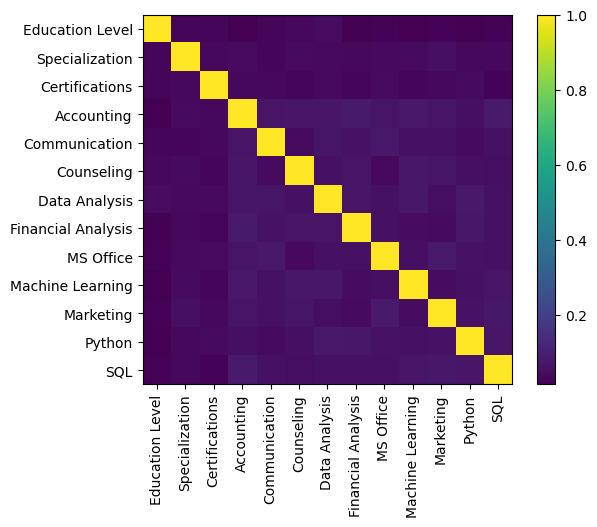

In [49]:
plt.imshow(cramers_vs)
plt.xticks(range(0, len(categorical_features), 1), labels=categorical_features, rotation='vertical')
plt.yticks(range(0, len(categorical_features), 1), labels=categorical_features)
plt.colorbar()
plt.show()

Vidimo na osnovu heat mape da su i atributi međusobno nezavisni.

Za određivanje povezanosti između numeričkih i nominalnih kategoričkih atributa, kao i ciljne promenljive, koristili smo ANOVA test. ANOVA test služi za procenjivanje da li dva atributa imaju istu srednju vrednost - nulta hipoteza pretpostavlja da atributi imaju istu srednju vrednost, a alternativna suprotno. Za neki prag (npr. 5%), ukoliko je p-vrednost testa manja od tog praga zaključujemo da su razlike između srednjih vrednosti atributa statistički značajne i tada možemo prihvatiti alternativnu hipotezu, tj. da atributi nemaju istu srednju vrednost. Ukoliko atributi imaju istu srednju vrednost to znači da nema velike razlike u vrednostima numeričkog atributa u odnosu na vrednosti kategoričkog, što znači da su vrednosti nasumično raspoređene u odnosu na vrednosti kategoričkog atributa što znači da oni nisu povezani.

In [50]:
groups = [group['CGPA/Percentage'].values for name, group in data.groupby('Recommended Career')]
f_stat, p_val = stats.f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_val)

F-statistic: 0.8836790741678817
p-value: 0.555756484811343


Na osnovu p-vrednosti testa zaključujemo da atribut CGPA/Percentage i Recommended Career nisu povezani.

In [51]:
statistics = []
data_for_ANOVA = data_with_separated_skills.join(data['CGPA/Percentage'])

for feature in data_for_ANOVA.columns:
    if feature=='CGPA/Percentage': continue
    groups = [group['CGPA/Percentage'].values for name, group in data_for_ANOVA.groupby(feature)]
    f_stat, p_val = stats.f_oneway(*groups)
    temp = (f_stat, p_val)
    statistics.append(temp)
    print(feature)
    print("F-statistic:", f_stat)
    print("p-value:", p_val)

Education Level
F-statistic: 0.7609477755376445
p-value: 0.5505768119586579
Specialization
F-statistic: 1.5537765585433703
p-value: 0.14438896671304563
Certifications
F-statistic: 0.3812358148907022
p-value: 0.8914131633104975
Accounting
F-statistic: 0.19046488884205542
p-value: 0.6625488270311688
Communication
F-statistic: 2.5993752241144144
p-value: 0.10696898905419706
Counseling
F-statistic: 3.236395228531841
p-value: 0.07207923824389201
Data Analysis
F-statistic: 0.6094036931135612
p-value: 0.43504938889390343
Financial Analysis
F-statistic: 1.5161038464524594
p-value: 0.21826798516803234
MS Office
F-statistic: 3.3465023275001
p-value: 0.06740751945353231
Machine Learning
F-statistic: 0.17793755467244216
p-value: 0.6731698395474814
Marketing
F-statistic: 0.14602714622528287
p-value: 0.702377490671299
Python
F-statistic: 0.6207008856338568
p-value: 0.430824313376591
SQL
F-statistic: 1.0148194559636667
p-value: 0.31379977566767825


Ukoliko bismo za prag uzeli vrednost 0.05 zaključili bi da nijedna od kategoričkih promenljivih nisu povezane sa numeričkim atributom CGPA/Percentage.

Kako je atribut Education Level ordinalni možemo koristiti Spirmanov koeficijent korelacije za određivanje korelacije između tog atributa i atributa CGPA/Percentage

In [52]:
df_for_corrs = data[['Education Level', 'CGPA/Percentage']]
df_for_corrs.corr(method='spearman')

,Education Level,CGPA/Percentage
Education Level,1.000000,0.007612
CGPA/Percentage,0.007612,1.000000


Zaključujemo da nema zavisnosti između atributa Education Level i CGPA/Percentage

Čuvamo pretprocesirane podatke u datoteku preprocessed_data.csv

In [53]:
data.to_csv('preprocessed_data.csv')